## Generating Data

          x    t  psi_real  psi_imag
0  0.000000  0.0  0.000000       0.0
1  0.010101  0.0  0.044870       0.0
2  0.020202  0.0  0.089695       0.0
3  0.030303  0.0  0.134430       0.0
4  0.040404  0.0  0.179029       0.0
5  0.050505  0.0  0.223448       0.0
6  0.060606  0.0  0.267642       0.0
7  0.070707  0.0  0.311566       0.0
8  0.080808  0.0  0.355177       0.0
9  0.090909  0.0  0.398430       0.0

Probability Conservation:
Minimum = 1.0000000000000002
Maximum = 1.000000000000055
Difference = 5.484501741648273e-14


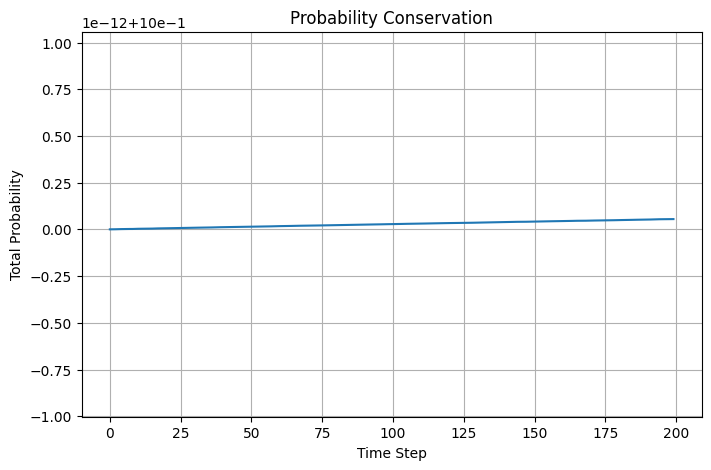


ANALYTICAL VALIDATION
Final time            = 0.200000
MSE                   = 7.123e-09
RMSE                  = 8.440e-05
Maximum absolute error= 1.199e-04


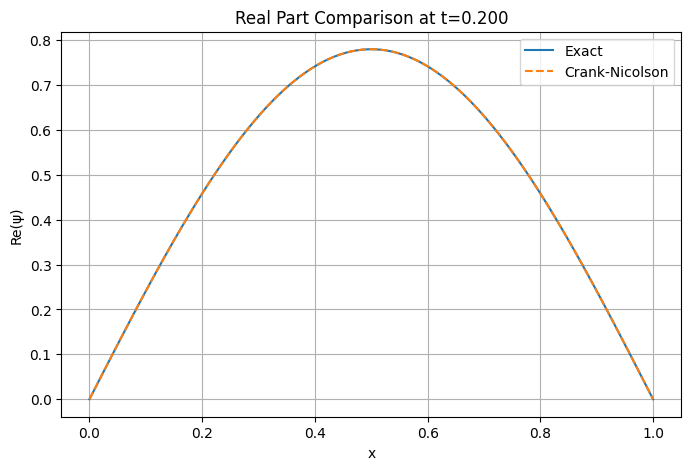

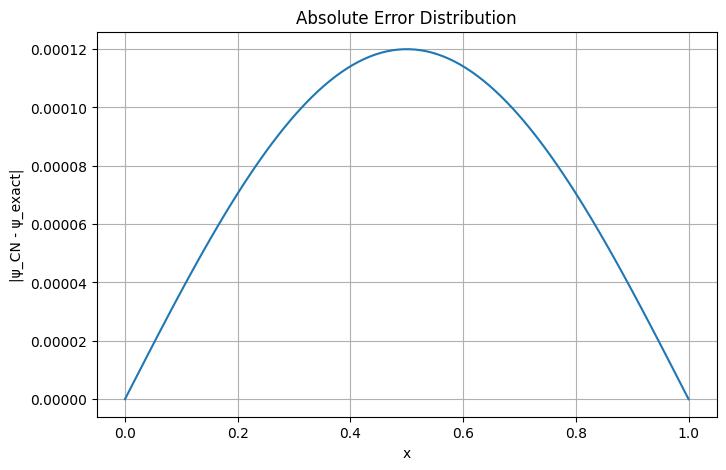

Saved as tdse_particle_in_box_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# Physical parameters (natural units)
hbar = 1.0
m = 1.0
L = 1.0

# Numerical parameters
Nx = 100
Nt = 200
dt = 0.001

x = np.linspace(0, L, Nx)
dx = x[1] - x[0]

# Initial condition (ground state), ψ(x,0) = sqrt(2) sin(pi x)
psi = np.sqrt(2) * np.sin(np.pi * x)
psi = psi.astype(complex)

# Boundary conditions
psi[0] = 0
psi[-1] = 0

# Crank-Nicolson matrices (Banded formulation)
r = 1j * hbar * dt / (4 * m * dx**2)
N_internal = Nx - 2

# We only need the dense B matrix for the matrix-vector multiplication
B = (
    np.diag((1 - 2 * r) * np.ones(N_internal))
    + np.diag(r * np.ones(N_internal - 1), 1)
    + np.diag(r * np.ones(N_internal - 1), -1)
)

# For A, we format it for scipy's solve_banded (l=1, u=1)
# Row 0: upper diagonal, Row 1: main diagonal, Row 2: lower diagonal
A_banded = np.zeros((3, N_internal), dtype=complex)
A_banded[0, 1:] = -r            # Upper diagonal
A_banded[1, :] = 1 + 2 * r      # Main diagonal
A_banded[2, :-1] = -r           # Lower diagonal

# Time evolution
data = []
probabilities = []

for n in range(Nt):
    t = n * dt

    # Check probability conservation (using the updated trapezoid function)
    P = np.trapezoid(np.abs(psi)**2, x)
    probabilities.append(P)

    # Save dataset
    for xi, p in zip(x, psi):
        data.append([xi, t, p.real, p.imag])

    # Crank-Nicolson update
    rhs = B @ psi[1:-1]

    # Solve the tridiagonal system efficiently
    psi_new_internal = solve_banded((1, 1), A_banded, rhs)

    psi[1:-1] = psi_new_internal

    # Boundary conditions
    psi[0] = 0
    psi[-1] = 0

# Create DataFrame
df = pd.DataFrame(
    data,
    columns=["x", "t", "psi_real", "psi_imag"]
)

df.to_csv("tdse_particle_box.csv", index=False)

# Preview dataset
print(df.head(10))

# Physics checks
print("\nProbability Conservation:")
print(f"Minimum = {np.min(probabilities)}")
print(f"Maximum = {np.max(probabilities)}")
print(f"Difference = {np.max(probabilities) - np.min(probabilities)}")

# Plot probability vs time
plt.figure(figsize=(8, 5))
plt.plot(probabilities)
plt.xlabel("Time Step")
plt.ylabel("Total Probability")
plt.title("Probability Conservation")
plt.grid(True)
plt.show()

# Analytical Validation
final_t = Nt * dt

# Exact energy of the ground state (n = 1)
E1 = np.pi**2 / 2

# Exact analytical solution
psi_exact = (
    np.sqrt(2)
    * np.sin(np.pi * x)
    * np.exp(-1j * E1 * final_t)
)

# Numerical solution (current psi after the last time step)
psi_numerical = psi.copy()

# Errors
mse = np.mean(np.abs(psi_numerical - psi_exact)**2)
rmse = np.sqrt(mse)
max_error = np.max(np.abs(psi_numerical - psi_exact))

print("\n" + "="*50)
print("ANALYTICAL VALIDATION")
print("="*50)
print(f"Final time            = {final_t:.6f}")
print(f"MSE                   = {mse:.3e}")
print(f"RMSE                  = {rmse:.3e}")
print(f"Maximum absolute error= {max_error:.3e}")

# Plot: Numerical vs Exact (Real Part)
plt.figure(figsize=(8, 5))
plt.plot(x, psi_exact.real, label="Exact")
plt.plot(x, psi_numerical.real, "--", label="Crank-Nicolson")

plt.xlabel("x")
plt.ylabel("Re(ψ)")
plt.title(f"Real Part Comparison at t={final_t:.3f}")
plt.legend()
plt.grid(True)
plt.show()


# Plot: Error Distribution
error = np.abs(psi_numerical - psi_exact)

plt.figure(figsize=(8, 5))
plt.plot(x, error)

plt.xlabel("x")
plt.ylabel("|ψ_CN - ψ_exact|")
plt.title("Absolute Error Distribution")
plt.grid(True)
plt.show()


# Save the dataset
filename = "tdse_particle_in_box_dataset.csv"
df.to_csv(filename, index=False)

print(f"Saved as {filename}")
from google.colab import files

files.download(filename)

## Data Reshaping

In [2]:
import pandas as pd
import numpy as np

# Load original dataset
df = pd.read_csv("tdse_particle_in_box_dataset.csv")

print("Original shape:")
print(df.shape)

# Unique time values
times = np.sort(df["t"].unique())

X = []   # Inputs (time)
Y = []   # Outputs (whole wavefunction)

# Group by time
for t in times:

    # Get all spatial points at this time
    temp = df[df["t"] == t].sort_values("x")

    # Extract real and imaginary parts
    psi_real = temp["psi_real"].values
    psi_imag = temp["psi_imag"].values

    # Combine them into one long vector
    psi_full = np.concatenate([psi_real, psi_imag])

    # Store
    X.append([t])
    Y.append(psi_full)

# Convert to NumPy arrays
X = np.array(X)
Y = np.array(Y)

# Check shapes
print("\nAfter reshaping:")
print("X shape =", X.shape)
print("Y shape =", Y.shape)


# Physics check again on reshaped data
dx = 1.0 / (100 - 1)

real = Y[0][:100]
imag = Y[0][100:]

probability = np.sum(real**2 + imag**2) * dx

print("\nProbability at t=0:")
print(probability)


# Create column names
real_cols = [f"real_{i}" for i in range(100)]
imag_cols = [f"imag_{i}" for i in range(100)]

columns = ["t"] + real_cols + imag_cols

# Create DataFrame
df_reshaped = pd.DataFrame(
    np.hstack([X, Y]),
    columns=columns
)

# Save
df_reshaped.to_csv(
    "tdse_particle_in_box_reshaped.csv",
    index=False
)

print("\nSaved reshaped dataset!")
print(df_reshaped.head())

from google.colab import files

files.download("tdse_particle_in_box_reshaped.csv")

Original shape:
(20000, 4)

After reshaping:
X shape = (200, 1)
Y shape = (200, 200)

Probability at t=0:
1.0000000000000002

Saved reshaped dataset!
       t  real_0    real_1    real_2    real_3    real_4    real_5    real_6  \
0  0.000     0.0  0.044870  0.089695  0.134430  0.179029  0.223448  0.267642   
1  0.001     0.0  0.044870  0.089694  0.134428  0.179027  0.223445  0.267638   
2  0.002     0.0  0.044868  0.089691  0.134423  0.179020  0.223437  0.267629   
3  0.003     0.0  0.044865  0.089685  0.134415  0.179009  0.223423  0.267612   
4  0.004     0.0  0.044861  0.089677  0.134403  0.178994  0.223404  0.267590   

     real_7    real_8  ...   imag_90   imag_91   imag_92   imag_93   imag_94  \
0  0.311566  0.355177  ...  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.311562  0.355173  ... -0.001966 -0.001753 -0.001537 -0.001321 -0.001103   
2  0.311551  0.355160  ... -0.003932 -0.003505 -0.003075 -0.002641 -0.002205   
3  0.311532  0.355138  ... -0.005898 -0.005258 -0

## Reshaping Again for Multi-Token Transformer Model

In [3]:
import pandas as pd
import numpy as np
from google.colab import files

# Load the one-token dataset
df = pd.read_csv("tdse_particle_in_box_reshaped.csv")

print("Original shape:")
print(df.shape)

# Inputs and outputs
times = df["t"].values.astype(np.float32)

# Remove time column
wavefunctions = df.drop(columns=["t"]).values.astype(np.float32)

# Sliding window parameters
window_size = 5

X_multi = []
Y_multi = []

# Create windows
for i in range(len(times) - window_size):

    # Input: [t_i, t_i+1, ..., t_i+4]
    input_window = times[i:i + window_size]

    # Output: ψ(t_i+5)
    target_wave = wavefunctions[i + window_size]

    X_multi.append(input_window)
    Y_multi.append(target_wave)

# Convert to NumPy arrays
X_multi = np.array(X_multi)
Y_multi = np.array(Y_multi)

# Check shapes
print("\nMulti-token shapes:")
print("X_multi shape =", X_multi.shape)
print("Y_multi shape =", Y_multi.shape)

# Physics check
dx = 1.0 / 99

real = Y_multi[0][:100]
imag = Y_multi[0][100:]

P = np.sum(real**2 + imag**2) * dx

print("\nProbability of first target sample:")
print(P)


# Create column names
time_cols = [f"t_{i}" for i in range(5)]

real_cols = [f"real_{i}" for i in range(100)]
imag_cols = [f"imag_{i}" for i in range(100)]

columns = time_cols + real_cols + imag_cols


# Combine X and Y
df_multi = pd.DataFrame(
    np.hstack([X_multi, Y_multi]),
    columns=columns
)


# Save CSV
filename = "tdse_particle_in_box_multitoken.csv"

df_multi.to_csv(filename, index=False)

print("Saved successfully!")
print(df_multi.head())

# Download it in system
# files.download(filename)

Original shape:
(200, 201)

Multi-token shapes:
X_multi shape = (195, 5)
Y_multi shape = (195, 200)

Probability of first target sample:
1.0000001
Saved successfully!
     t_0    t_1    t_2    t_3    t_4  real_0    real_1    real_2    real_3  \
0  0.000  0.001  0.002  0.003  0.004     0.0  0.044856  0.089668  0.134389   
1  0.001  0.002  0.003  0.004  0.005     0.0  0.044850  0.089656  0.134371   
2  0.002  0.003  0.004  0.005  0.006     0.0  0.044843  0.089641  0.134349   
3  0.003  0.004  0.005  0.006  0.007     0.0  0.044835  0.089625  0.134325   
4  0.004  0.005  0.006  0.007  0.008     0.0  0.044826  0.089607  0.134297   

     real_4  ...   imag_90   imag_91   imag_92   imag_93   imag_94   imag_95  \
0  0.178974  ... -0.009829 -0.008762 -0.007686 -0.006603 -0.005512 -0.004417   
1  0.178950  ... -0.011794 -0.010514 -0.009223 -0.007923 -0.006614 -0.005300   
2  0.178922  ... -0.013759 -0.012266 -0.010760 -0.009243 -0.007716 -0.006183   
3  0.178889  ... -0.015724 -0.014017 -0.0122